In [ ]:
import os
import glob

from nd280mlreco import dataloader

from torch_geometric.transforms import RadiusGraph
from torch_geometric import data as tg_data
from torch_geometric import utils as tg_utils
from torch_geometric.loader import DataLoader

import networkx as nx

import math as m

from matplotlib import pyplot as plt

import typing

In [ ]:
VALIDATION_SPLIT = 0.7
MAX_RADIUS = 50.0

input_files = glob.glob("/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_*.pt")
input_files.sort()

def make_datasets(
        input_files:typing.List[str],
        max_radius,
        validation_split = 0.7,
    ) -> typing.Tuple[dataloader.HATDataset]:
        
    ## index to split the file names according to the VALIDATION_SPLIT ratio
    n_train = m.floor(validation_split* len(input_files))
    train_files = input_files[:n_train]
    validation_files = input_files[n_train:]

    ## make lists of processed file names
    processed_train_files = []
    processed_validation_files = []

    for i, input_file in enumerate(input_files):
        file_name = os.path.split(input_file)[-1] 

        if i < n_train:
            processed_train_files.append(file_name)
        else:
            processed_validation_files.append(file_name)

    ## check that the size of the lists matches between raw and processed files
    assert(len(processed_train_files) == len(train_files))
    assert(len(processed_validation_files) == len(validation_files))

    print(f"N Train files: {len(train_files)}")
    print(f"N Validation files: {len(validation_files)}")

    ## make the training data set
    train_set = dataloader.HATDataset(
        raw_filenames = train_files, 
        processed_file_names = processed_train_files,
        root = "/home/ewan/ND280-ML/nd280-ml-reco/processed_files/train",
        pre_transform = RadiusGraph(max_radius)
        )

    train_set.process()

    ## make the validation dataset
    validation_set = dataloader.HATDataset(
        raw_filenames = validation_files, 
        processed_file_names = processed_validation_files,
        root = "/home/ewan/ND280-ML/nd280-ml-reco/processed_files/validation",
        pre_transform = RadiusGraph(max_radius)
        )

    validation_set.process()

    return train_set, validation_set

Train files: ['/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_0.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_10.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_100.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_1000.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_1001.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_1002.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_1005.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_1006.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_1007.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_1008.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_1009.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_101.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_1010.pt', '/home/ewan/ND280-ML/nd280-ml-reco/gnn-test-files/data_HAT_1011.pt', '/home/ewan/ND280-ML/nd280-

Processing...
/home/ewan/ND280-ML/nd280-ml-reco/nd280mlreco/dataloader.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(raw_path)
Done!
Processing...
D

In [ ]:
def plot_input(data:dataloader.HATDataset) -> None:
    """ Plots the "input" graph from a data object 

    :param data: The data object to plot from
    :type data: dataloader.HATDataset
    """

    draw_options = {
        'node_color': 'black',
        'width': 0.2,
    }
    
    g = tg_utils.to_networkx(data, to_undirected=True, remove_self_loops=True)
    plt.clf()
    nx.draw(g, data.pos[:, :-1], node_size = data.x / 20.0, **draw_options)
    plt.title("Example data graph")

def plot_truth(data:dataloader.HATDataset) -> None:
    """ Plots the "label" graph from a data object

    :param data: The data object to plot from
    :type data: dataloader.HATDataset
    """
    
    plt.clf()

    label = tg_data.Data(
        edge_index = data.edge_label_index, 
        pos = data.pos,
        x = data.y
    ) 

    g = tg_utils.to_networkx(label, to_undirected=True, remove_self_loops=True)
    plt.clf()

    node_colours = []
    for i in range(len(label.x)):
        if label.x[i][0] and label.x[i][1]:
            node_colours.append('m')
        else:
            if label.x[i][0]:
                node_colours.append('b')
            elif label.x[i][1]:
                node_colours.append('r')
            else:
                node_colours.append('k')

    nx.draw(g, label.pos[:, :-1], node_size = data.x / 20.0, width = 1, node_color = node_colours)

def plot_prediction(data:dataloader.HATDataset, logits, thresh:float = 0.5):
    """ Plot predicted labels on top of the input graph that was used to make the predictions 

    :param data: The data object that was given to the model
    :type data: dataloader.HATDataset
    :param logits: The logits outputted by the model
    :type logits: Array Like
    :param thresh: The threshold to apply to the logits to get a binary prediction
    :type thresh: float
    """

    plt.clf()

    g = tg_utils.to_networkx(data, to_undirected=True, remove_self_loops=True)
    
    node_colours = []
    for i in range(len(logits)):
        if logits[i][0] > thresh and logits[i][1] > thresh:
            node_colours.append('m')
        else:
            if logits[i][0] > thresh:
                node_colours.append('b')
            elif logits[i][1] > thresh:
                node_colours.append('r')
            else:
                node_colours.append('k')

    nx.draw(g, data.pos[:, :-1], node_size = data.x / 20.0, width = 1, node_color = node_colours)

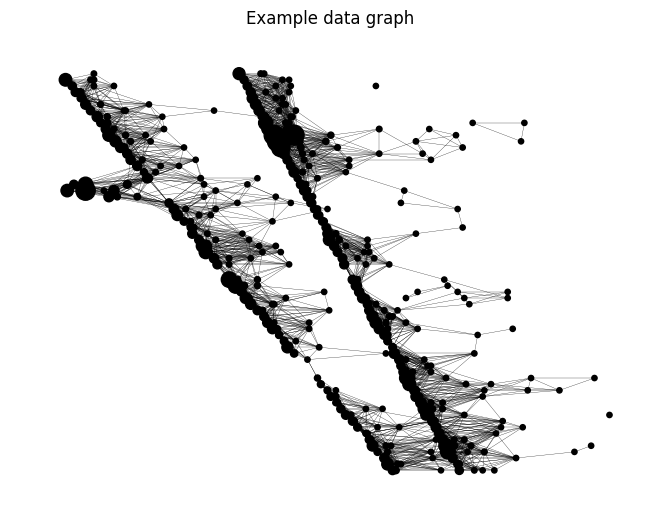

In [94]:

EXAMPLE_INDEX = 1

data = train_set.get(EXAMPLE_INDEX)

plot_input(data)
plt.savefig( os.path.join(f"data_graph_example.png") )


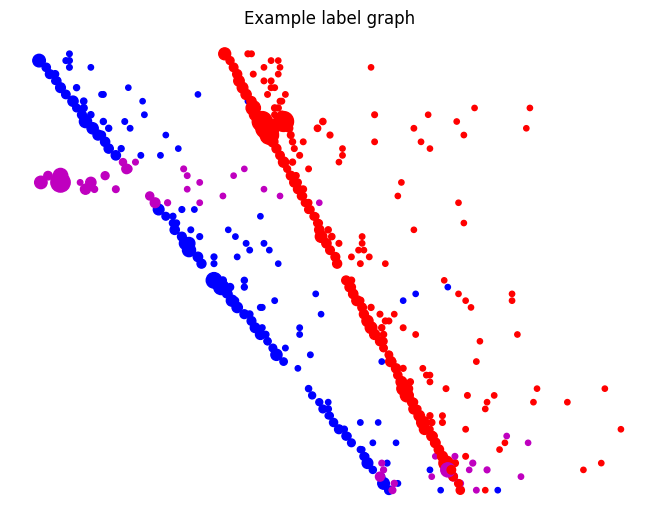

In [95]:
plot_truth(data)
plt.title("Example label graph")
plt.savefig( os.path.join(f"label_graph_example.png") )

In [96]:
from torch.nn import Linear, ReLU, Sigmoid
from torch_geometric.nn import Sequential, GCNConv
from torch.optim import Adam
from torch.nn import MSELoss, CrossEntropyLoss
from torch_geometric.nn.conv import PointNetConv
from torcheval.metrics import BinaryAccuracy
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import torch

train_loader = DataLoader(train_set, batch_size=64)
val_loader = DataLoader(validation_set)

INTERNAL_NODES = 150

local_nn_0 = Sequential("x",
                [(Linear(4, INTERNAL_NODES), "x -> x"),
                ReLU(),
                Linear(INTERNAL_NODES, INTERNAL_NODES)],
            )

local_nn_1 = Sequential("x",
                [(Linear(INTERNAL_NODES+3, INTERNAL_NODES), "x -> x"),
                ReLU(),
                Linear(INTERNAL_NODES, INTERNAL_NODES)],
            )

global_nn = Sequential("x",
                [(Linear(INTERNAL_NODES, INTERNAL_NODES), "x -> x"),
                ReLU(),
                Linear(INTERNAL_NODES, INTERNAL_NODES)],
            )

model = Sequential(
    'x, pos, edge_index', 
    [
        (PointNetConv( 
            local_nn_0,
            global_nn,
        ), 'x, pos, edge_index -> x'),

        (PointNetConv( 
            local_nn_1,
            global_nn,
        ), 'x, pos, edge_index -> x'),

        (PointNetConv( 
            local_nn_1,
            global_nn,
        ), 'x, pos, edge_index -> x'),

        (PointNetConv( 
            local_nn_1,
            global_nn,
        ), 'x, pos, edge_index -> x'),

        (ReLU(inplace=True), "x -> x"),
        (Linear(INTERNAL_NODES, 2), "x -> x"),
        (Sigmoid(), "x -> x")
    ]
)

model.compile()

optimizer = Adam(model.parameters(), lr = 0.005)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter(log_dir = 'runs/GCN_trainer_{}'.format(timestamp))
epoch_number = 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EPOCHS = 50

checkpoint = torch.load("checkpoints/20250331_165805")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch']

def train_one_epoch(epoch_index, tb_writer, print_freq=None):
    running_loss = 0.0
    bin_accuracy = BinaryAccuracy()

    for i, data in enumerate(train_loader):

        data.to(device)
        
        optimizer.zero_grad()

        # Make predictions for this batch
        feat = data.x.to(torch.float32) / 1000.0
        pos = data.pos.to(torch.float32) / 2500.0

        outputs = model(feat, pos, data.edge_index)

        # Compute the loss and its gradients
        loss = CrossEntropyLoss()(outputs, data.y.to(torch.float32))
        bin_accuracy.update(outputs.flatten(), data.y.to(torch.float32).flatten())
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()

        if print_freq is not None and i %print_freq == 0:
            print(f"    - step {i}: loss: {loss.item()}, acc: {bin_accuracy.compute()}")


    last_loss = running_loss / i # loss per batch
    print(f'  Train loss: {last_loss}: accuracy: {bin_accuracy.compute()}')
    tb_x = epoch_index * len(train_loader) + i + 1
    tb_writer.add_scalar('Loss/train', last_loss, tb_x)
    tb_writer.add_scalar('binary_accuracy/train', bin_accuracy.compute(), tb_x)

    return last_loss 



def validate_one_epoch(epoch_index, tb_writer):

    running_loss = 0.0
    bin_accuracy = BinaryAccuracy()
    
    for i, data_val in enumerate(val_loader):

        data_val.to(device)

        # Make predictions for this batch
        outputs = model(data_val.x.to(torch.float32) / 1000.0, data_val.pos.to(torch.float32) / 2500.0, data_val.edge_index)

        # Compute the loss and its gradients
        loss = CrossEntropyLoss()(outputs, data_val.y.to(torch.float32))
        bin_accuracy.update(outputs.flatten(), data_val.y.to(torch.float32).flatten())

        # Gather data and report
        running_loss += loss.item()

    last_loss = running_loss / i # loss per batch
    print(f'  Validation loss: {last_loss}: accuracy: {bin_accuracy.compute()}')
    tb_x = epoch_index * len(val_loader) + i + 1
    tb_writer.add_scalar('Loss/validation', last_loss, tb_x)
    tb_writer.add_scalar('binary_accuracy/validation', bin_accuracy.compute(), tb_x)
    
    return last_loss

final_epoch = 0
final_train_loss = 0.0
final_val_loss = 0.0

for i in range(start_epoch + 1, start_epoch + EPOCHS):

    print(f'#####  Epoch {i} #####')
    
    final_epoch = i
    final_train_loss = train_one_epoch(i, writer, print_freq = 100)
    final_val_loss = validate_one_epoch(i, writer)



/tmp/ipykernel_845247/4097147563.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("checkpoints/20250331_165805")


RuntimeError: Error(s) in loading state_dict for Sequential:
	Missing key(s) in state_dict: "module_3.local_nn.module_0.weight", "module_3.local_nn.module_0.bias", "module_3.local_nn.module_2.weight", "module_3.local_nn.module_2.bias", "module_3.global_nn.module_0.weight", "module_3.global_nn.module_0.bias", "module_3.global_nn.module_2.weight", "module_3.global_nn.module_2.bias", "module_5.weight", "module_5.bias". 
	Unexpected key(s) in state_dict: "module_4.weight", "module_4.bias". 
	size mismatch for module_0.local_nn.module_0.weight: copying a param with shape torch.Size([100, 4]) from checkpoint, the shape in current model is torch.Size([150, 4]).
	size mismatch for module_0.local_nn.module_0.bias: copying a param with shape torch.Size([100]) from checkpoint, the shape in current model is torch.Size([150]).
	size mismatch for module_0.local_nn.module_2.weight: copying a param with shape torch.Size([100, 100]) from checkpoint, the shape in current model is torch.Size([150, 150]).

In [ ]:
torch.save({
            'epoch': final_epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': final_train_loss,
            'val_loss': final_val_loss,
            }, f"checkpoints/{timestamp}")

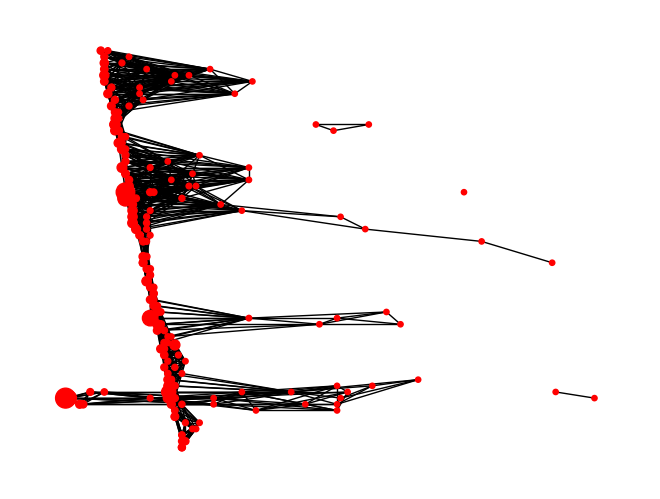

In [ ]:
VAL_EXAMPLE_INDEX = 407

outputs = model(
    validation_set[VAL_EXAMPLE_INDEX].x.to(torch.float32), 
    validation_set[VAL_EXAMPLE_INDEX].pos.to(torch.float32), 
    validation_set[VAL_EXAMPLE_INDEX].edge_index
)

plot_prediction(validation_set[VAL_EXAMPLE_INDEX], outputs, thresh = 0.0)
#print("labels:", validation_set[VAL_EXAMPLE_INDEX].y)